In [1]:
import numpy as np
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\PC\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Aug 27 21:52:43 2026).


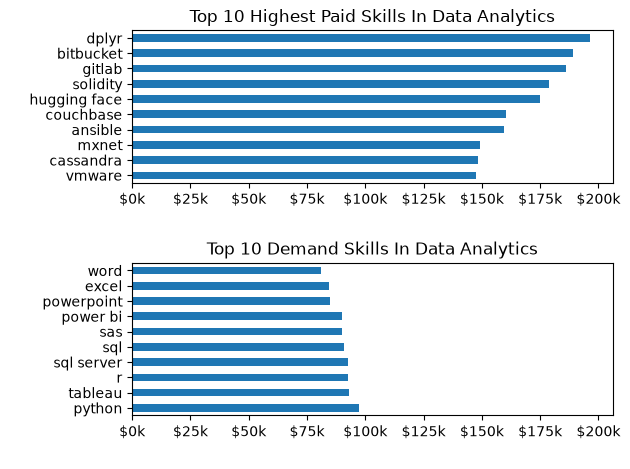

In [2]:
df_usa = df[
    (df['job_title_short'] == 'Data Analyst')
    & (df['job_country'] == 'United States')
]

df_DA_USA = (
    df_usa[['salary_year_avg', 'job_skills']]
    .dropna(subset=['salary_year_avg'])
    .explode('job_skills')
)

df_DA_USA_group=df_DA_USA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_USA_top_pay=df_DA_USA_group.sort_values(by= 'median', ascending=False).head(10)
df_DA_USA_skills =df_DA_USA_group.sort_values(by='count', ascending= False).head(10).sort_values(by= 'median', ascending=False)

fig, ax= plt.subplots(2,1)
df_DA_USA_top_pay.plot(kind='barh', y='median', ax= ax[0], legend= False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills In Data Analytics')
ax[0].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[0].set_xlabel(' ')
ax[0].set_ylabel(' ')

df_DA_USA_skills.plot(kind='barh', y='median', ax= ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Demand Skills In Data Analytics')
ax[1].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[1].set_xlabel(' ')
ax[1].set_ylabel(' ')

fig.tight_layout()

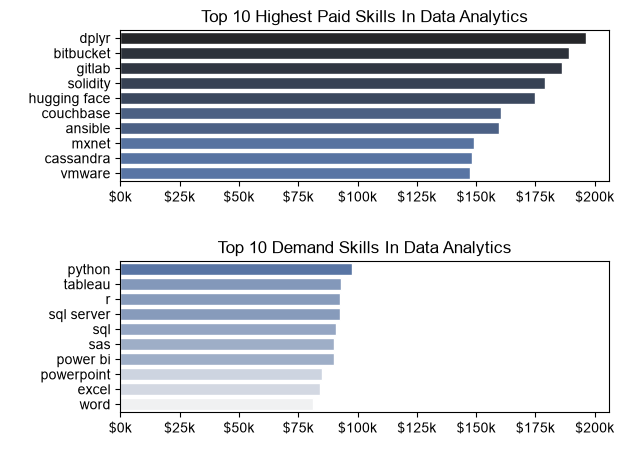

In [8]:


fig, ax= plt.subplots(2,1)

sns.set_theme(style='ticks')
sns.barplot(data=df_DA_USA_top_pay, x='median', y=df_DA_USA_top_pay.index, ax=ax[0], hue= 'median', palette='dark:b_r')
#df_DA_USA_top_pay.plot(kind='barh', y='median', ax= ax[0], legend= False)
#ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills In Data Analytics')
ax[0].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[0].set_xlabel(' ')
ax[0].set_ylabel(' ')
ax[0].legend().remove()

sns.barplot(data=df_DA_USA_skills, x='median', y=df_DA_USA_skills.index, ax=ax[1],hue= 'median', palette='light:b')
#df_DA_USA_skills.plot(kind='barh', y='median', ax= ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Demand Skills In Data Analytics')
ax[1].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[1].set_xlabel(' ')
ax[1].set_ylabel(' ')
ax[1].legend().remove()

fig.tight_layout()

In [10]:
df_analyst= df[df['job_title_short']== 'Data Analyst']
df_analyst=df_analyst.dropna(subset=['salary_year_avg'])
df_analyst

147750    115000.0
483120    111175.0
613684     75067.5
304941    115000.0
136168     85000.0
769211     53014.0
222674     75000.0
189308     45000.0
752063     53338.0
311253    125931.0
Name: salary_year_avg, dtype: float64

Text(0, 0.5, 'Job Counts')

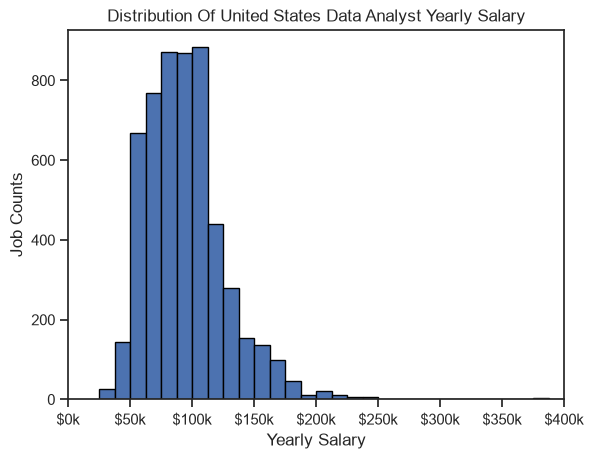

In [11]:
from tkinter import N


df_analyst['salary_year_avg'].plot(kind='hist', bins=50, edgecolor='black')
plt.xlim(0, 400000)
ax = plt.gca()
ax.xaxis.set_major_formatter(lambda y, pos: f'${int(y/1000)}k')
plt.title('Distribution Of United States Data Analyst Yearly Salary')
plt.xlabel('Yearly Salary')
plt.ylabel('Job Counts')

Text(12.444444444444445, 0.5, 'Job Counts')

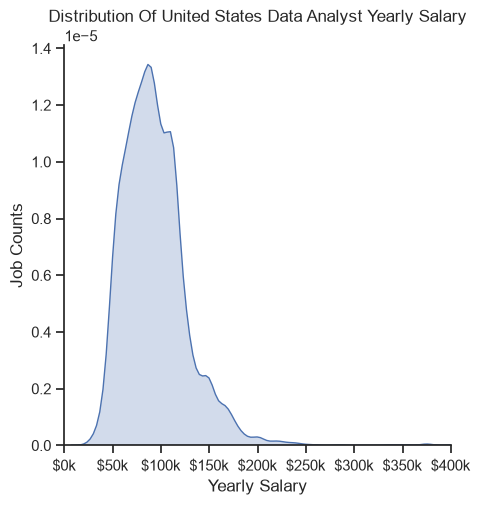

In [15]:
from statistics import kde
from tkinter import N

sns.displot(df_analyst['salary_year_avg'], kind='kde', fill=True)
plt.xlim(0, 400000)
ax = plt.gca()
ax.xaxis.set_major_formatter(lambda y, pos: f'${int(y/1000)}k')
plt.title('Distribution Of United States Data Analyst Yearly Salary')
plt.xlabel('Yearly Salary')
plt.ylabel('Job Counts')

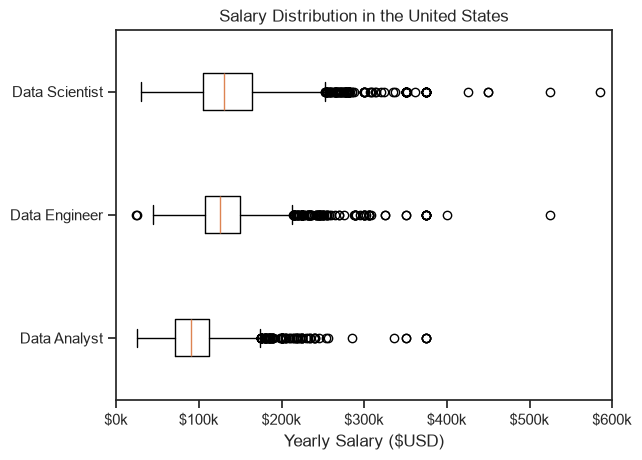

In [16]:
job_title = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_usa = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(job_title))].copy()
df_usa = df_usa.dropna(subset=['salary_year_avg'])

job_list = [df_usa[df_usa['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_title]

plt.boxplot(job_list, orientation='horizontal')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.yticks(range(1, len(job_title) + 1), job_title)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 600000)
plt.show()

In [ ]:
salary_df = df_usa[df_usa['job_title_short'].isin(job_title)][['job_title_short', 'salary_year_avg']].dropna()
salary_df['job_title_short'] = pd.Categorical(salary_df['job_title_short'], categories=job_title, ordered=True)

sns.boxplot(
    data=salary_df,
    x='salary_year_avg',
    y='job_title_short',
    order=job_title,
    orient='h'
)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('Job Title')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 600000)
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'list'>.